In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ITERATIONS = 100000     
NUM_PLAYERS = 6         
BUY_IN = 200            
DARK_BET = 500

In [ ]:
def is_win(hand, center):
    c_rank, c_suit = center
    for p_rank, p_suit in hand:
        if p_suit == c_suit:
            # กฎพิเศษ 2 ชนะ A
            if p_rank == 2 and c_rank == 14: return True
            if p_rank == 14 and c_rank == 2: continue
            if p_rank > c_rank: return True
    return False

def calc_win_prob(hand):
    deck_base = [(r, s) for r in range(2, 15) for s in ['C', 'D', 'H', 'S']]
    unknown_cards = [c for c in deck_base if c not in hand]
    
    wins = sum(1 for center in unknown_cards if is_win(hand, center))
    return wins / len(unknown_cards)

def simulate_v4_prob_based():
    deck_base = [(r, s) for r in range(2, 15) for s in ['C', 'D', 'H', 'S']]
    balances = np.zeros(NUM_PLAYERS)
    pot = NUM_PLAYERS * BUY_IN
    balances -= BUY_IN
    
    history = [balances.copy()]
    pot_refills = 0

    for _ in range(ITERATIONS):
        deck = deck_base[:]
        random.shuffle(deck)
        
        center = deck[0]
        hands = [deck[1 + i*4 : 1 + (i+1)*4] for i in range(NUM_PLAYERS)]
        
        for i in range(NUM_PLAYERS):
            if pot <= 0:
                pot_refills += 1
                balances -= BUY_IN
                pot += NUM_PLAYERS * BUY_IN
                
            hand = hands[i]
            won = is_win(hand, center)
            
            if i == 0:
                bet_amount = min(DARK_BET, pot)
                if won:
                    balances[i] += bet_amount
                    pot -= bet_amount
                else:
                    balances[i] -= bet_amount * 0.5
                    pot += bet_amount * 0.5
            else:
                p_win = calc_win_prob(hand)
                bet_amount = pot * p_win  
                
                bet_amount = int(bet_amount) 
                
                if bet_amount > 0:
                    if won:
                        balances[i] += bet_amount
                        pot -= bet_amount
                    else:
                        balances[i] -= bet_amount
                        pot += bet_amount
                        
        history.append(balances.copy())

    return np.array(history), pot_refills

In [7]:
history_data, total_refills = simulate_v4_prob_based()

print(f"==================================================")
print(f"📊 สรุปผลการเล่น 1 มืด vs 5 นับไพ่ ({ITERATIONS:,} รอบ)")
print(f"💰 เติมกองกลางไปทั้งหมด: {total_refills:,} ครั้ง")
print(f"--------------------------------------------------")
print(f"P1 (สายมืด - แทง 500): {history_data[-1][0]:,.0f} บาท")
for i in range(1, NUM_PLAYERS):
    print(f"P{i+1} (สายสว่างนับไพ่ - แทงตาม Prob): {history_data[-1][i]:,.0f} บาท")
print(f"==================================================")

print("English Summary:")
print(f"==================================================")
print(f"📊 Simulation Summary: 1 Dark vs 5 Prob-Light ({ITERATIONS:,} Rounds)")
print(f"💰 Total Pot Refills: {total_refills:,} times")
print(f"--------------------------------------------------")
print(f"P1 (Dark Strategy - Bet 500): {history_data[-1][0]:,.0f} THB")
for i in range(1, NUM_PLAYERS):
    print(f"P{i+1} (Prob-Light Strategy - Proportional Bet): {history_data[-1][i]:,.0f} THB")
print(f"==================================================")

📊 สรุปผลการเล่น 1 มืด vs 5 นับไพ่ (100,000 รอบ)
💰 เติมกองกลางไปทั้งหมด: 8,087 ครั้ง
--------------------------------------------------
P1 (สายมืด - แทง 500): 1,594,154 บาท
P2 (สายสว่างนับไพ่ - แทงตาม Prob): -712,073,866,213,564 บาท
P3 (สายสว่างนับไพ่ - แทงตาม Prob): 740,058,817,655,128 บาท
P4 (สายสว่างนับไพ่ - แทงตาม Prob): 906,690,685,346,320 บาท
P5 (สายสว่างนับไพ่ - แทงตาม Prob): 46,594,250,288,688 บาท
P6 (สายสว่างนับไพ่ - แทงตาม Prob): -981,269,888,673,942 บาท
English Summary:
📊 Simulation Summary: 1 Dark vs 5 Prob-Light (100,000 Rounds)
💰 Total Pot Refills: 8,087 times
--------------------------------------------------
P1 (Dark Strategy - Bet 500): 1,594,154 THB
P2 (Prob-Light Strategy - Proportional Bet): -712,073,866,213,564 THB
P3 (Prob-Light Strategy - Proportional Bet): 740,058,817,655,128 THB
P4 (Prob-Light Strategy - Proportional Bet): 906,690,685,346,320 THB
P5 (Prob-Light Strategy - Proportional Bet): 46,594,250,288,688 THB
P6 (Prob-Light Strategy - Proportional Bet): -981

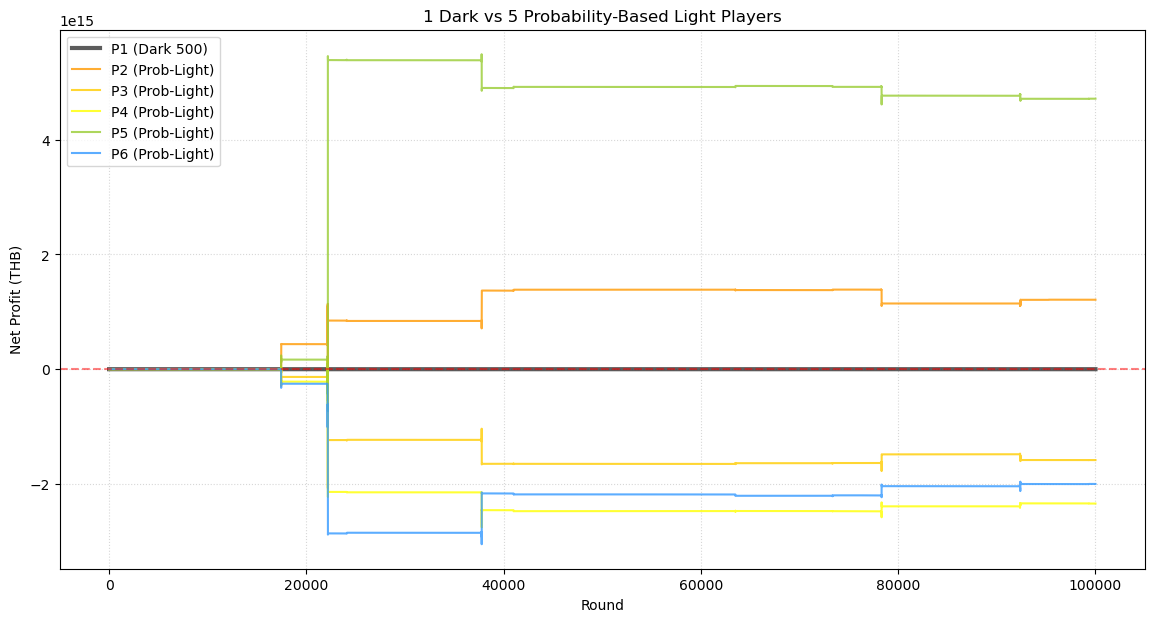

In [6]:
plt.figure(figsize=(14, 7))
colors = ['#333333', '#FF9900', '#FFCC00', '#FFFF00', '#99CC33', '#3399FF']
for i in range(NUM_PLAYERS):
    label = "P1 (Dark 500)" if i == 0 else f"P{i+1} (Prob-Light)"
    linewidth = 3 if i == 0 else 1.5
    plt.plot(history_data[:, i], label=label, color=colors[i], linewidth=linewidth, alpha=0.8)

plt.title('1 Dark vs 5 Probability-Based Light Players')
plt.xlabel('Round')
plt.ylabel('Net Profit (THB)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Light Strategy is better when people don't have an emotion and budget (stop-loss)